<a href="https://colab.research.google.com/github/sultanjacob/Applied-Machine-Learning/blob/main/03_clustering/01_Data_Engineering_and_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Install the Dunnhumby Complete Journey dataset package
!pip install completejourney_py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.6/31.6 MB 40.0 MB/s eta 0:00:00


In [3]:
import pandas as pd
from completejourney_py import get_data

# Load all datasets into a dictionary
data = get_data()

# Extract the two specific tables we are going to merge and clean
transactions = data["transactions"]
demographics = data["demographics"]

print(f"Loaded {len(transactions):,} transaction records")
print(f"Covering {len(demographics):,} households")

# Let's peek at the chaos
display(transactions.head())
display(demographics.head())

Loaded 1,469,307 transaction records
Covering 801 households


,household_id,store_id,basket_id,product_id,quantity,sales_value,retail_disc,coupon_disc,coupon_match_disc,week,transaction_timestamp
0,900,330,31198570044,1095275,1,0.50,0.00,0.0,0.0,1,2017-01-01 11:53:26
1,900,330,31198570047,9878513,1,0.99,0.10,0.0,0.0,1,2017-01-01 12:10:28
2,1228,406,31198655051,1041453,1,1.43,0.15,0.0,0.0,1,2017-01-01 12:26:30
3,906,319,31198705046,1020156,1,1.50,0.29,0.0,0.0,1,2017-01-01 12:30:27
4,906,319,31198705046,1053875,2,2.78,0.80,0.0,0.0,1,2017-01-01 12:30:27


,household_id,age,income,home_ownership,marital_status,household_size,household_comp,kids_count
0,1,65+,35-49K,Homeowner,Married,2,2 Adults No Kids,0
1,1001,45-54,50-74K,Homeowner,Unmarried,1,1 Adult No Kids,0
2,1003,35-44,25-34K,None,Unmarried,1,1 Adult No Kids,0
3,1004,25-34,15-24K,None,Unmarried,1,1 Adult No Kids,0
4,101,45-54,Under 15K,Homeowner,Married,4,2 Adults Kids,2


We want to do Exploratory Data Analysis and check datatypes, find missing values and duplicates.

In [4]:
# --- STEP 2: Check Data Types ---
print("--- TRANSACTIONS DATA TYPES ---")
print(transactions.dtypes)
print("\n--- DEMOGRAPHICS DATA TYPES ---")
print(demographics.dtypes)

# --- STEP 3: Find Missing Values ---
print("\n--- MISSING VALUES ---")
print("Transactions:\n", transactions.isna().sum())
print("\nDemographics:\n", demographics.isna().sum())

# --- STEP 4: Check Duplicates ---
print("\n--- DUPLICATE ROWS ---")
print(f"Duplicate Transactions: {transactions.duplicated().sum():,}")
print(f"Duplicate Demographics: {demographics.duplicated().sum():,}")

# --- STEP 5: Review Summary Statistics ---
print("\n--- TRANSACTIONS SUMMARY (Numerical) ---")
display(transactions.describe())

print("\n--- DEMOGRAPHICS SUMMARY (Categorical) ---")
# include='all' is used because demographics is mostly text/categorical data
display(demographics.describe(include='all'))

--- TRANSACTIONS DATA TYPES ---
household_id                      int64
store_id                          int64
basket_id                         int64
product_id                        int64
quantity                          int64
sales_value                     float64
retail_disc                     float64
coupon_disc                     float64
coupon_match_disc               float64
week                              int64
transaction_timestamp    datetime64[ns]
dtype: object

--- DEMOGRAPHICS DATA TYPES ---
household_id       int64
age               object
income            object
home_ownership    object
marital_status    object
household_size    object
household_comp    object
kids_count        object
dtype: object

--- MISSING VALUES ---
Transactions:
 household_id             0
store_id                 0
basket_id                0
product_id               0
quantity                 0
sales_value              0
retail_disc              0
coupon_disc              0
coupon_match

,household_id,store_id,basket_id,product_id,quantity,sales_value,retail_disc,coupon_disc,coupon_match_disc,week,transaction_timestamp
count,1.469307e+06,1.469307e+06,1.469307e+06,1.469307e+06,1.469307e+06,1.469307e+06,1.469307e+06,1.469307e+06,1.469307e+06,1.469307e+06,1469307
mean,1.275241e+03,3.247428e+03,3.540096e+10,3.084897e+06,1.040784e+02,3.128032e+00,5.387919e-01,1.794036e-02,3.091696e-03,2.736753e+01,2017-07-02 14:58:07.551236352
min,1.000000e+00,2.000000e+00,3.119844e+10,2.567100e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,2017-01-01 11:53:26
25%,6.620000e+02,3.300000e+02,3.255695e+10,9.195340e+05,1.000000e+00,1.290000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.400000e+01,2017-04-01 23:31:00
50%,1.282000e+03,3.720000e+02,3.394460e+10,1.029968e+06,1.000000e+00,2.000000e+00,1.000000e-02,0.000000e+00,0.000000e+00,2.700000e+01,2017-07-02 15:17:58
75%,1.916000e+03,4.220000e+02,4.019859e+10,1.138189e+06,1.000000e+00,3.490000e+00,6.800000e-01,0.000000e+00,0.000000e+00,4.100000e+01,2017-10-02 16:28:34
max,2.500000e+03,3.428000e+04,4.148128e+10,1.795946e+07,8.963800e+04,8.400000e+02,1.300200e+02,5.593000e+01,7.700000e+00,5.300000e+01,2018-01-01 04:01:20
std,7.256484e+02,9.098922e+03,3.572285e+09,4.057064e+06,1.174392e+03,4.290385e+00,1.263224e+00,2.345139e-01,4.199046e-02,1.510671e+01,NaN



--- DEMOGRAPHICS SUMMARY (Categorical) ---


,household_id,age,income,home_ownership,marital_status,household_size,household_comp,kids_count
count,801.000000,801,801,568,664,801,801,801
unique,NaN,6,12,4,2,5,4,4
top,NaN,45-54,50-74K,Homeowner,Married,2,2 Adults No Kids,0
freq,NaN,288,192,504,340,318,258,513
mean,1235.176030,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,736.804647,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,596.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,1218.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1914.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Visualizing Distributions and Outliers

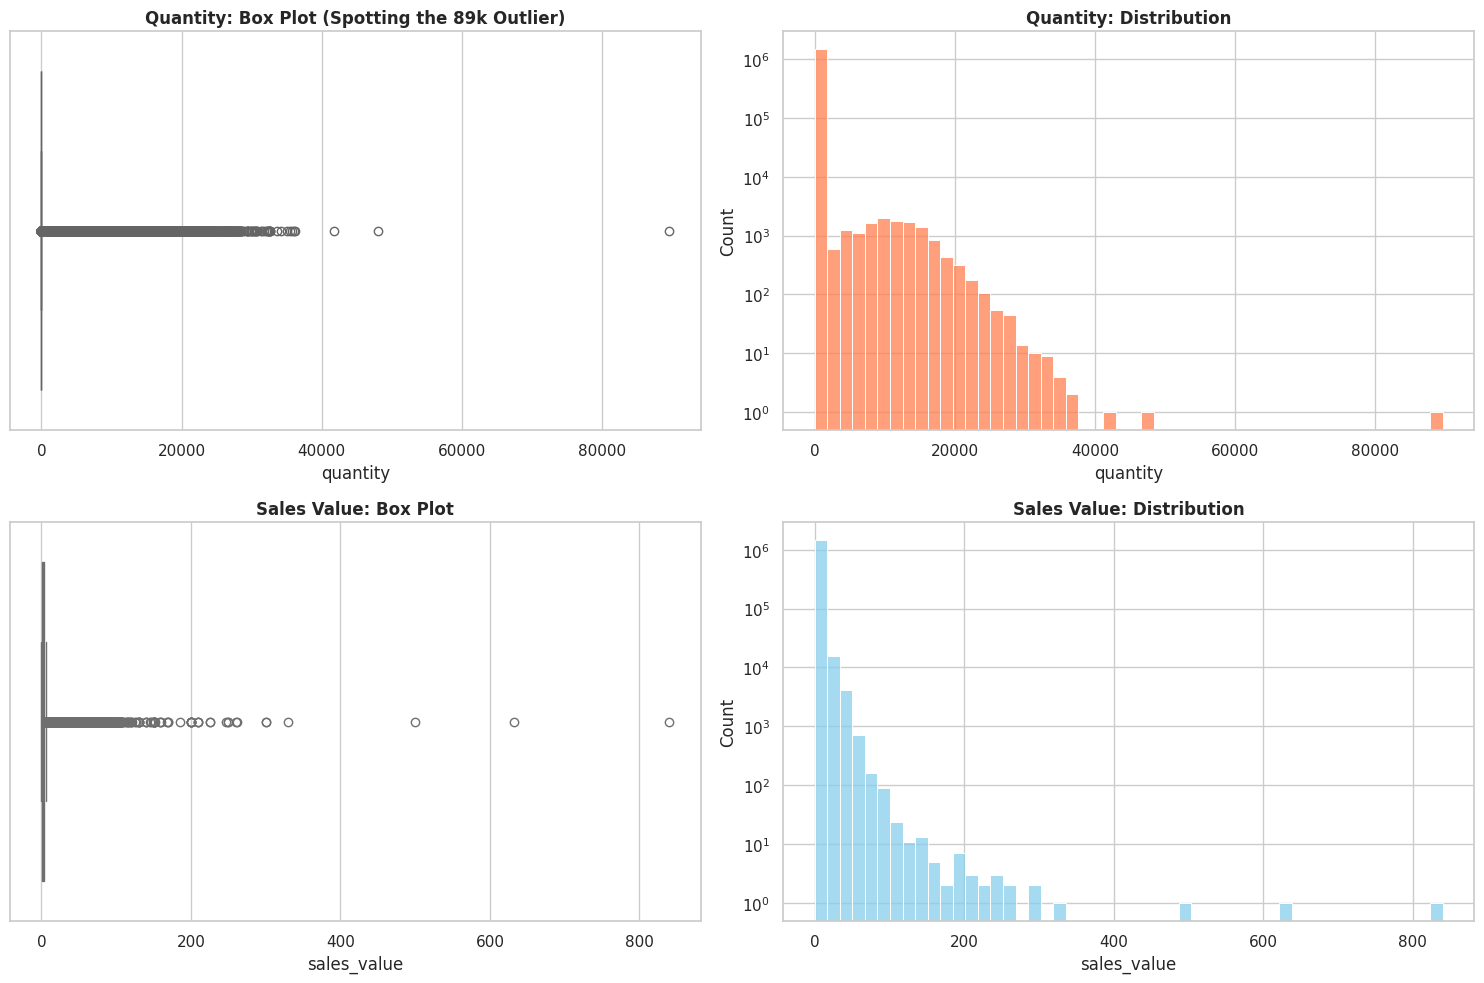

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, modern aesthetic for our charts
sns.set_theme(style="whitegrid")

# Create a dashboard layout: 2 rows, 2 columns
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# --- ROW 1: THE QUANTITY METRIC ---
# 1A. Box Plot to spot the massive outlier
sns.boxplot(x=transactions['quantity'], ax=axes[0, 0], color='coral')
axes[0, 0].set_title('Quantity: Box Plot (Spotting the 89k Outlier)', fontweight='bold')

# 1B. Histogram to see general purchasing behavior
sns.histplot(transactions['quantity'], bins=50, ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Quantity: Distribution', fontweight='bold')
axes[0, 1].set_yscale('log') # Log scale because 99% of data is small, 1% is massive

# --- ROW 2: THE SALES VALUE METRIC ---
# 2A. Box Plot for Sales Value
sns.boxplot(x=transactions['sales_value'], ax=axes[1, 0], color='skyblue')
axes[1, 0].set_title('Sales Value: Box Plot', fontweight='bold')

# 2B. Histogram for Sales Value
sns.histplot(transactions['sales_value'], bins=50, ax=axes[1, 1], color='skyblue')
axes[1, 1].set_title('Sales Value: Distribution', fontweight='bold')
axes[1, 1].set_yscale('log')

plt.tight_layout()
plt.show()

# 1. The Quantity Row (Top)
* Box Plot (Top Left):
This chart beautifully illustrates the danger of outliers. That single, isolated circle hovering near the 90,000 mark on the far right is our massive anomaly. Because it is so extreme, it forces the "box" (which contains the other 1.4 million normal transactions) to be completely squashed into an invisible line on the far left.

* Distribution (Top Right): This is a log-scaled histogram. The massive orange bar on the far left proves that the vast majority of customers are buying very small quantities (likely 1 to 10 items) per transaction. The frequency drops off exponentially as the quantity increases.

# 2. The Sales Value Row (Bottom)

* Box Plot (Bottom Left):
Just like the quantity chart, the sales value is heavily skewed. While the vast majority of normal grocery trips are clustered tightly near $0–$50, we have a few extreme shopping sprees stretching all the way up to $800+.

* Distribution (Bottom Right):
This shows a classic "long-tail" retail distribution. The highest blue bars indicate that low-dollar transactions are the most common, with rare, high-dollar purchases trailing off slowly to the right.

# Phase 2: Data Engineering & Preprocessing for Clustering

To prepare our raw transaction logs for **k-Means Clustering**, we execute a 4-step data engineering pipeline:
1. **(Outlier Removal):** Filter out extreme data entry errors (such as the 89,000+ item quantity anomaly and zero/negative sales values).
2. **Customer-Level Aggregation (Feature Engineering):** Aggregate 1.4+ million raw item transactions into household-level behavioral metrics (Total Spend, Total Visits, Average Basket Size, Total Quantity).
3. **Demographic Preprocessing:** Encode categorical demographic buckets (Age, Income, Kids) into structured, ordinal numerical values.
4. **Relational Merging:** Merge the household behavioral metrics with the demographic profiles to form the final feature matrix for clustering.

### Step 1: Outlier Removal & Data Filtering
We filter out invalid transactions where `quantity <= 0` or `sales_value <= 0`, as well as extreme anomalies where `quantity > 1000` or `sales_value > 500`.

In [6]:
# Initial row count
initial_rows = len(transactions)

# Filter out non-positive transactions and extreme volume/price anomalies
clean_transactions = transactions[
    (transactions['quantity'] > 0) &
    (transactions['quantity'] <= 1000) &
    (transactions['sales_value'] > 0) &
    (transactions['sales_value'] <= 500)
].copy()

dropped_rows = initial_rows - len(clean_transactions)
print(f"Step 1 Complete: Sliced out {dropped_rows:,} anomaly rows.")
print(f"Remaining valid transactions: {len(clean_transactions):,}")

Step 1 Complete: Sliced out 24,771 anomaly rows.
Remaining valid transactions: 1,444,536


### Step 2: Customer Aggregation (RFM & Basket Metrics)
k-Means groups *households*, not individual item scans. We aggregate the transaction logs by `household_id` to create 4 core behavioral features:
* `total_spend`: Lifetime spend across the entire period.
* `total_quantity`: Total volume of items purchased.
* `total_transactions`: Total shopping trips (unique `basket_id` count).
* `avg_basket_value`: Average spend per trip (`total_spend / total_transactions`).

In [7]:
# Aggregate transactions at household level
household_behavior = clean_transactions.groupby('household_id').agg(
    total_spend=('sales_value', 'sum'),
    total_quantity=('quantity', 'sum'),
    total_transactions=('basket_id', 'nunique'),
    avg_item_price=('sales_value', 'mean')
).reset_index()

# Derive Average Basket Value (Spend per trip)
household_behavior['avg_basket_value'] = (
    household_behavior['total_spend'] / household_behavior['total_transactions']
)

print(f"Step 2 Complete: Aggregated {len(household_behavior):,} unique household behavioral profiles.")
display(household_behavior.head())

Step 2 Complete: Aggregated 2,467 unique household behavioral profiles.


,household_id,total_spend,total_quantity,total_transactions,avg_item_price,avg_basket_value
0,1,2415.56,1130,50,2.492838,48.311200
1,2,1024.12,406,20,2.868683,51.206000
2,3,1006.62,619,19,2.819664,52.980000
3,4,442.14,144,18,3.983243,24.563333
4,5,299.67,95,20,3.525529,14.983500


### Step 3: Cleaning & Encoding Demographics
Demographic features like `age`, `income`, and `kids_count` are stored as text ranges. We map these ranges to ordinal numerical scales so distance-based clustering algorithms can measure differences accurately.

In [8]:
clean_demographics = demographics.copy()

# 1. Fill missing marital status and home ownership with an explicit category
clean_demographics['marital_status'] = clean_demographics['marital_status'].fillna('Unknown')
clean_demographics['home_ownership'] = clean_demographics['home_ownership'].fillna('Unknown')

# 2. Encode Age Ranges to Ordinal Numbers (midpoint proxy)
age_map = {
    '19-24': 1,
    '25-34': 2,
    '35-44': 3,
    '45-54': 4,
    '55-64': 5,
    '65+': 6
}
clean_demographics['age_encoded'] = clean_demographics['age'].map(age_map)

# 3. Encode Income Ranges to Ordinal Scale
income_map = {
    'Under 15K': 1,
    '15-24K': 2,
    '25-34K': 3,
    '35-49K': 4,
    '50-74K': 5,
    '75-99K': 6,
    '100-124K': 7,
    '125-149K': 8,
    '150-174K': 9,
    '175-199K': 10,
    '200-249K': 11,
    '250K+': 12
}
clean_demographics['income_encoded'] = clean_demographics['income'].map(income_map)

# 4. Clean kids_count (treat '3+' as 3)
kids_map = {'0': 0, '1': 1, '2': 2, '3+': 3}
clean_demographics['kids_encoded'] = clean_demographics['kids_count'].map(kids_map)

print(f"Step 3 Complete: Processed {len(clean_demographics):,} demographic profiles.")
display(clean_demographics[['household_id', 'age_encoded', 'income_encoded', 'kids_encoded', 'home_ownership']].head())

Step 3 Complete: Processed 801 demographic profiles.


,household_id,age_encoded,income_encoded,kids_encoded,home_ownership
0,1,6,4,0,Homeowner
1,1001,4,5,0,Homeowner
2,1003,3,3,0,Unknown
3,1004,2,2,0,Unknown
4,101,4,1,2,Homeowner
